In [1]:
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
d = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv", index_col=0)
d = d[(d["Time"] == 3) & (d["ActD"].isna()) & (d["UMIs"] > 5000)]
info = d[(d["Cell_Type"] == "K562") & (d["s4U"] == 0)]
print(info.shape)

(190, 49)


In [5]:
array = []
for cell in info.index:
    d = pd.read_csv("../../../1_NanoNASCseq/results/5_expression/5_isoform_category/%s/%s.tsv" % (cell.split(".")[0], cell), sep="\t")
    data = dict()
    for name, tmp in d.groupby(by="Name"):
        data[name] = list(sorted(tmp["Category"]))
    counter = defaultdict(int)
    for name, cats in data.items():
        if len(cats) == 1:
            if cats[0] in ['FSM', 'MonoExonFSM']:
                counter['FSM'] += 1
            else:
                counter['ISM'] += 1
        else:
            cats = list(set(cats))
            if len(cats) == 1 and cats[0] == "FSM":
                counter["FSM"] += 1
            else:
                counter["MultiIsoform"] += 1
    array.append(counter)

In [6]:
m1 = pd.DataFrame(array)
m1 = m1[['FSM', 'ISM', 'MultiIsoform']]
m1

,FSM,ISM,MultiIsoform
0,8611,2039,5892
1,6380,1729,4561
2,10328,2743,7560
3,8584,2508,7475
4,5059,1236,4674
...,...,...,...
185,2978,1104,3186
186,1746,880,2451
187,1642,627,1750
188,2033,742,2241


In [7]:
m2 = m1.divide(m1.sum(axis=1), axis=0)

FSM	0.487831903808961	0.04500289463448424
ISM	0.1271832559803809	0.014355764626465583
MultiIsoform	0.3849848402106581	0.03679865319296223


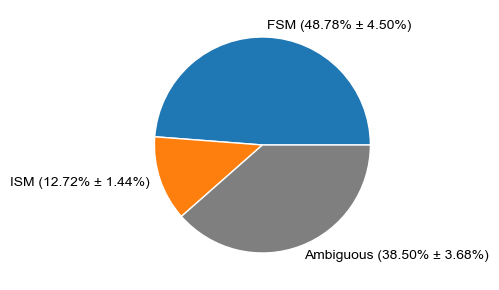

In [8]:
means = m2.mean()
stds = m2.std()
labels = ["FSM", "ISM", "Ambiguous"]
labels2 = []
for name, mean, std, label in zip(m2.columns, means, stds, labels):
    print(name, mean, std, sep='\t')
    labels2.append("%s (%.2f%% ± %.2f%%)" % (label, mean*100, std*100))

plt.figure(figsize=(5, 3))
plt.pie(means, 
        labels=labels2, 
        wedgeprops=dict(edgecolor="white"), 
        colors=["C0", "C1", "C7"])
plt.tight_layout()
plt.savefig("figures/percentage_of_isoform_assignment.pdf")
plt.show()
plt.close()